# 📚 Professional Styling & Export: theme, palette, save formats
> Section 12 of the Data Visualization curriculum (Matplotlib → Seaborn → Plotly → Tableau)
> 데이터 시각화 커리큘럼 섹션 12 (Matplotlib → Seaborn → Plotly → Tableau)

---
# 🎯 Learning Objective (학습 목표)
Today I want to learn / 오늘 배우고 싶은 것:
- [x] Control a chart's background/grid (`style`) and its size for the medium (`context`)<br>차트의 배경·격자(style)와 매체에 맞는 크기(context) 제어하기
- [x] Apply one consistent brand color palette across every chart in a report, wrapped in a reusable function<br>보고서의 모든 차트에 일관된 브랜드 컬러 팔레트를 적용하고, 재사용 가능한 함수로 감싸기
- [x] Choose the right file format and resolution (PNG/SVG/PDF, dpi) for how a chart will be used<br>차트의 용도에 맞는 올바른 파일 포맷과 해상도(PNG/SVG/PDF, dpi) 선택하기

---
# 🧠 Concept (개념)

## What is it? (이것은 무엇인가?)
*(Explain it in your own words.)*

**EN:** This section isn't a new chart type — it's the layer of polish that turns a working chart into one you'd actually hand to a stakeholder. Seaborn's *theme system* controls two independent things: `style` (background and gridlines) and `context` (the scale of fonts, lines, and markers for a given medium). On top of that, you fix a *color palette* once so every chart in a report matches, wrap the whole setup into one *function* so you stop retyping it, and finally choose the right *file format* (PNG/SVG/PDF) for how the chart will be used.

**KR:** 이번 섹션은 새로운 차트 유형이 아니라, 동작하는 차트를 실제로 이해관계자에게 건넬 수 있는 수준으로 다듬는 층입니다. Seaborn의 테마 시스템은 서로 독립된 두 가지를 제어합니다: style(배경과 격자선)과 context(매체에 맞는 글자·선·마커의 크기). 여기에 더해 색상 팔레트를 한 번 고정해 보고서의 모든 차트가 일치하게 만들고, 전체 설정을 함수 하나로 묶어 반복 타이핑을 없애며, 마지막으로 차트의 용도에 맞는 파일 포맷(PNG/SVG/PDF)을 선택합니다.

### style options (5 built-ins / 5가지 내장 스타일)

| `style` | Background / 배경 | Grid / 격자 |
|---|---|---|
| `darkgrid` (default/기본값) | Gray / 회색 | White grid / 흰색 격자 |
| `whitegrid` | White / 흰색 | Gray grid / 회색 격자 |
| `dark` | Gray / 회색 | None / 없음 |
| `white` | White / 흰색 | None / 없음 |
| `ticks` | White / 흰색 | None, tick marks instead / 없음, 축 눈금으로 대체 |

### context options (4 sizes / 4가지 용도별 크기)

| `context` | Relative size / 상대 크기 | Use case / 용도 |
|---|---|---|
| `paper` | Smallest, 0.8x / 가장 작음, 0.8배 | Papers, printed docs / 논문, 인쇄 문서 |
| `notebook` (default/기본값) | Normal, 1.0x / 보통, 1.0배 | Jupyter, everyday work / 주피터, 일반 작업 |
| `talk` | Large, 1.5x / 큼, 1.5배 | Presentation slides / 프레젠테이션 슬라이드 |
| `poster` | Largest, 2.0x / 가장 큼, 2.0배 | Posters, large screens / 포스터, 대형 스크린 |

## Why do we use it? (왜 사용하는가?)
*(When is it useful?)*

**EN:** The exact same chart can look like a "rough draft" or "board-ready" purely based on styling — and doing that by hand, one `rcParams` line at a time, in every single script is slow and inconsistent. A theme system gets you 90% of the way to a polished look in one function call, a fixed palette keeps colors from drifting between charts in the same report, and knowing the right export format saves you from blurry printed charts or images nobody can re-edit later.

**KR:** 완전히 똑같은 차트도 스타일링에 따라 "초안"처럼 보일 수도, "발표 가능"한 수준으로 보일 수도 있습니다 — 이를 매 스크립트마다 rcParams 한 줄씩 손으로 하는 것은 느리고 일관성도 없습니다. 테마 시스템은 함수 호출 한 번으로 완성도의 90%를 얻게 해주고, 고정 팔레트는 같은 보고서 안에서 색이 흔들리지 않게 하며, 올바른 내보내기 포맷을 아는 것은 흐릿하게 인쇄되거나 나중에 재편집할 수 없는 이미지를 피하게 해줍니다.

## When is it used in Business Analytics? (비즈니스 분석에서 언제 사용되는가?)
*(Real-world use case)*

**EN:** Right before you share results — the moment your analysis moves from "does this chart show what I think it shows" to "can I put this in front of leadership." A weekly report you rebuild every Monday is exactly when a reusable `setup_plot_style()` function pays for itself; a live presentation is exactly when `context='talk'` matters; a chart bound for a print handout is exactly when `dpi=300` matters.

**KR:** 결과를 공유하기 직전 — 분석이 "이 차트가 내가 생각한 것을 보여주는가"에서 "이걸 경영진 앞에 내놓을 수 있는가"로 넘어가는 순간입니다. 매주 월요일 다시 만드는 주간 보고서라면 재사용 가능한 setup_plot_style() 함수가 정확히 그 순간 값어치를 하고, 실시간 발표에서는 context='talk'이, 인쇄물로 나갈 차트에서는 dpi=300이 정확히 그 순간 중요해집니다.

---
# 📝 Syntax (문법)

## Basic Syntax (기본 문법)

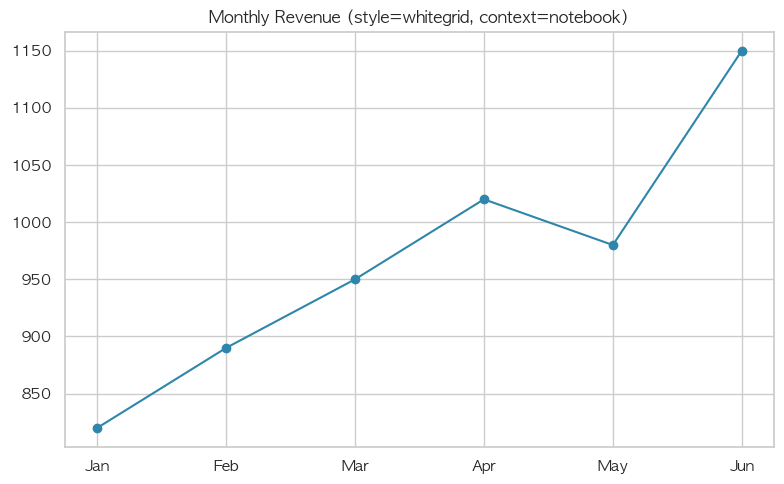

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# The theme system controls two independent things:
# style (background/grid) and context (size for the medium: paper/notebook/talk/poster)
# 테마 시스템은 독립된 두 가지를 제어합니다: style(배경·격자)과 context(매체별 크기)
sns.set_theme(style='whitegrid', font='AppleGothic')   # style + font in ONE call
plt.rcParams['axes.unicode_minus'] = False

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
revenue = [820, 890, 950, 1020, 980, 1150]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(months, revenue, marker='o', color='#2E86AB')
ax.set_title('Monthly Revenue (style=whitegrid, context=notebook)')
plt.tight_layout()
plt.show()

## Common Variations (자주 쓰는 변형)

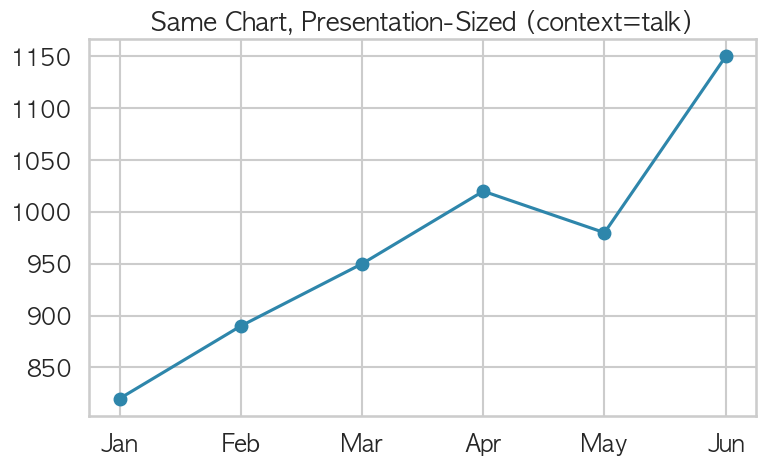

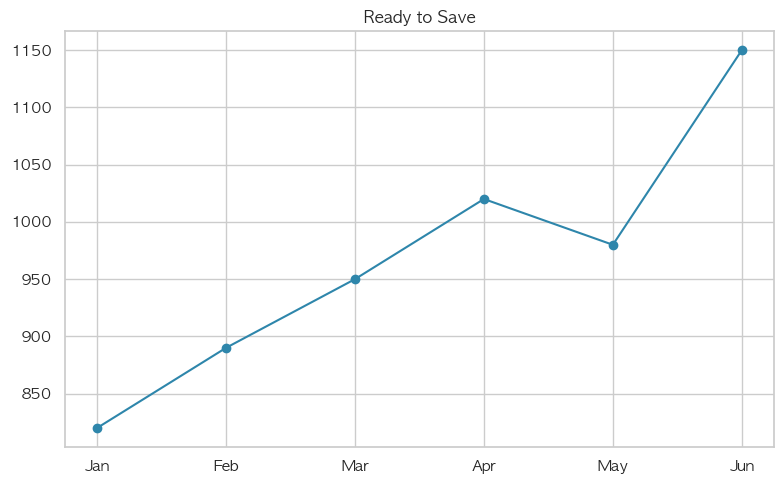

In [3]:
# 1) set_palette(): fix a brand color list once; every chart drawn after reuses it in order
# set_palette(): 브랜드 컬러 리스트를 한 번 고정하면 이후 모든 차트가 순서대로 재사용
sns.set_palette(['#2E86AB', '#4C956C', '#F4A261'])

# 2) set_context(): scale everything up for a live presentation, then reset it
# set_context(): 실시간 발표를 위해 전체 크기를 키운 뒤 다시 되돌림
sns.set_context('talk')
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(months, revenue, marker='o')
ax.set_title('Same Chart, Presentation-Sized (context=talk)')
plt.tight_layout()
plt.show()
sns.set_context('notebook')  # reset so later cells aren't affected

# 3) savefig with bbox_inches='tight' -- avoids clipped titles/labels
# bbox_inches='tight'를 넣은 savefig -- 제목·라벨이 잘리는 것을 방지
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(months, revenue, marker='o')
ax.set_title('Ready to Save')
plt.tight_layout()
# fig.savefig('syntax_demo.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🧪 Small Examples (예제)

## Example 1 — style: Comparing All Five Built-in Styles (다섯 가지 기본 스타일 비교)

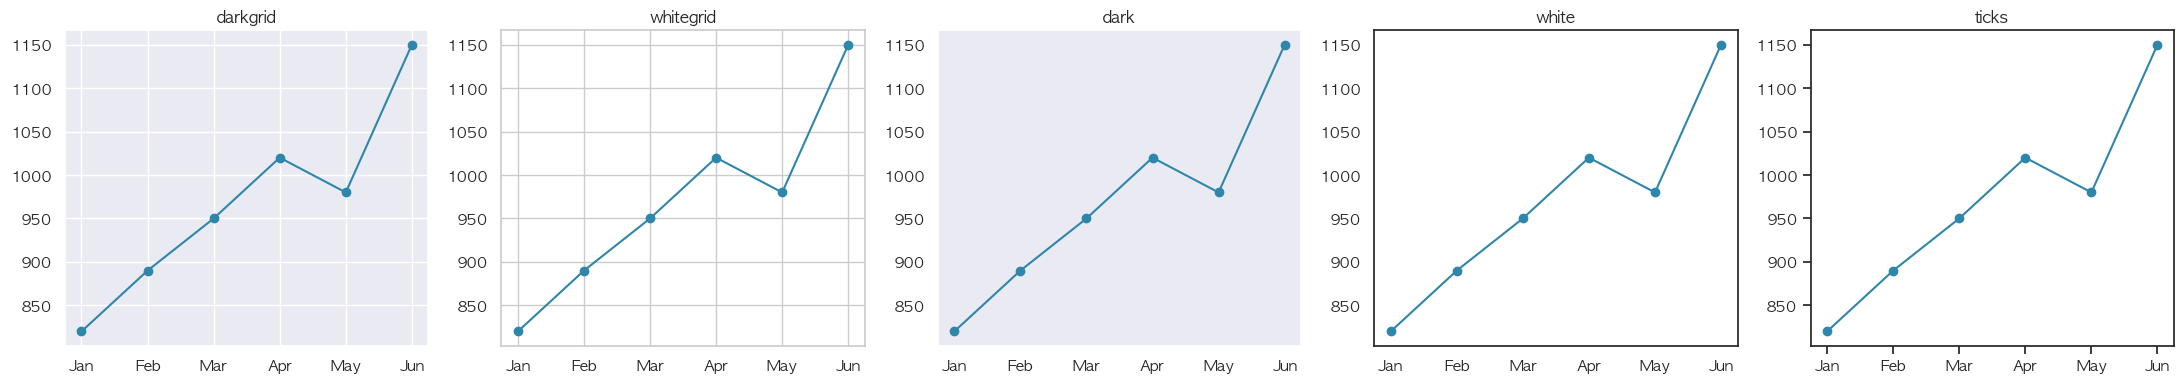

Order matters: set_style() only affects Axes created AFTER it runs, and it also
resets the font -- re-apply the font on every iteration, after set_style().
순서가 중요합니다: set_style()은 그 이후에 만들어지는 Axes에만 적용되고 폰트도
초기화하므로, 매 반복마다 set_style() '이후'에 폰트를 다시 지정해야 합니다.


In [4]:
# Business question: which built-in style fits a screen dashboard vs a printed report?
# 비즈니스 질문: 어떤 기본 스타일이 화면 대시보드에, 어떤 것이 인쇄 보고서에 어울리는가?

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
revenue = [820, 890, 950, 1020, 980, 1150]

styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
fig = plt.figure(figsize=(22, 4))

for i, style in enumerate(styles):
    sns.set_style(style)                            # 1) set the style FIRST
    plt.rcParams['font.family'] = 'AppleGothic'      # 2) THEN re-set the font (set_style resets it)
    plt.rcParams['axes.unicode_minus'] = False
    ax = fig.add_subplot(1, 5, i + 1)                # 3) create the Axes AFTER the style is set
    ax.plot(months, revenue, marker='o', color='#2E86AB')
    ax.set_title(style)

plt.tight_layout()
plt.show()

print("Order matters: set_style() only affects Axes created AFTER it runs, and it also")
print("resets the font -- re-apply the font on every iteration, after set_style().")
print("순서가 중요합니다: set_style()은 그 이후에 만들어지는 Axes에만 적용되고 폰트도")
print("초기화하므로, 매 반복마다 set_style() '이후'에 폰트를 다시 지정해야 합니다.")

## Example 2 — context: Sizing for Screen vs Slide vs Poster (화면·슬라이드·포스터별 크기)

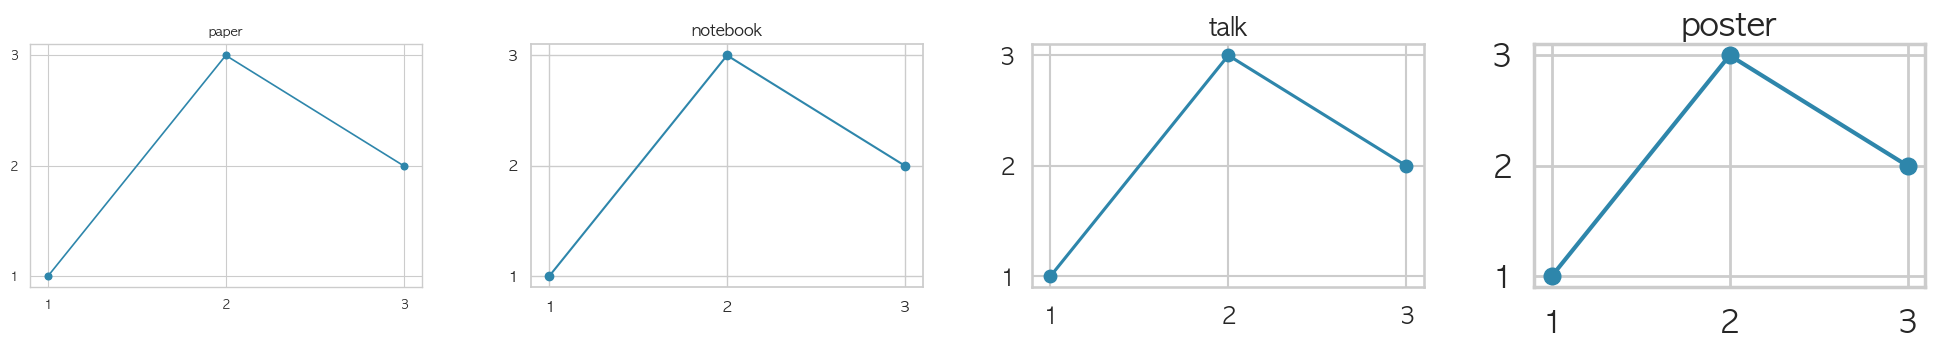

Rule of thumb: use context='talk' for anything projected or presented live.
경험칙: 화면에 투사하거나 발표할 자료에는 항상 context='talk'을 사용하세요.


In [5]:
# Business question: why does a chart that looks fine on your laptop become
# unreadable once projected onto a conference-room screen?
# 비즈니스 질문: 노트북에서는 괜찮아 보이던 차트가 회의실 화면에 띄우면 왜 안 읽히는가?

sns.set_theme(style='whitegrid', font='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

contexts = ['paper', 'notebook', 'talk', 'poster']
fig = plt.figure(figsize=(20, 4))
for i, ctx in enumerate(contexts):
    sns.set_context(ctx)
    ax = fig.add_subplot(1, 4, i + 1)
    ax.plot([1, 2, 3], [1, 3, 2], marker='o', color='#2E86AB')
    ax.set_title(ctx)
plt.tight_layout()
plt.show()

sns.set_context('notebook')  # reset to default for later cells

print("Rule of thumb: use context='talk' for anything projected or presented live.")
print("경험칙: 화면에 투사하거나 발표할 자료에는 항상 context='talk'을 사용하세요.")

## Example 3 — palette: A Consistent Brand Color Scheme (일관된 브랜드 컬러 팔레트)

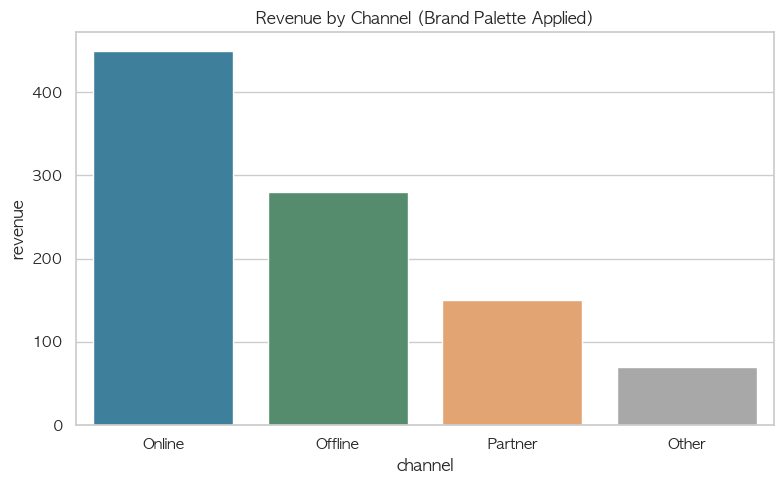

In [6]:
# Business question: how do you make every chart in a report use the same brand
# colors without re-typing hex codes in every cell?
# 비즈니스 질문: 매 셀마다 hex 코드를 다시 입력하지 않고 보고서의 모든 차트에
# 같은 브랜드 컬러를 쓰려면 어떻게 해야 하는가?

sns.set_theme(style='whitegrid', font='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

brand_palette = ['#2E86AB', '#4C956C', '#F4A261', '#A8A8A8']
sns.set_palette(brand_palette)   # every chart drawn after this line reuses these colors, in order

df = pd.DataFrame({'channel': ['Online', 'Offline', 'Partner', 'Other'], 'revenue': [450, 280, 150, 70]})

fig, ax = plt.subplots(figsize=(8, 5))
# IMPORTANT: hue=<same column as x> + legend=False is required to cycle the palette per bar
# (x= alone paints every bar with only the palette's FIRST color, in Seaborn 0.12+)
sns.barplot(data=df, x='channel', y='revenue', hue='channel', legend=False, ax=ax)
ax.set_title('Revenue by Channel (Brand Palette Applied)')
plt.tight_layout()
plt.show()

## Example 4 — Wrapping Style Setup into One Reusable Function (스타일 설정을 함수 하나로 묶기)

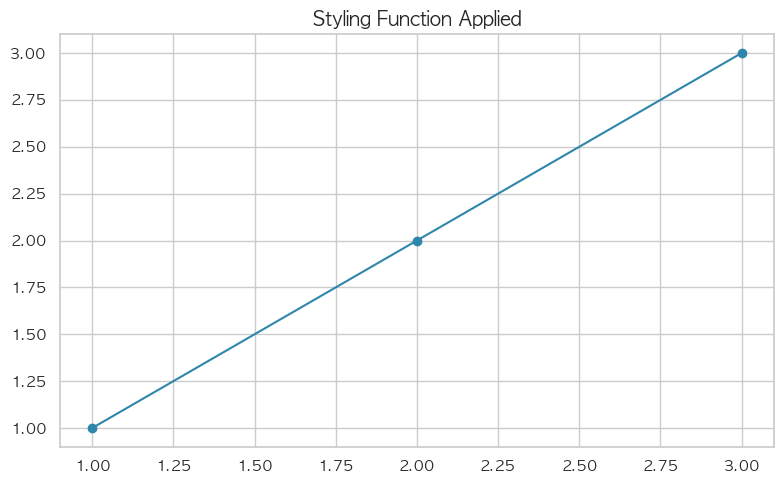

sns.set_theme(style=..., font=...) sets style AND font in one call, so there's no
ordering trap to remember -- this is why it's the preferred way to combine them.
sns.set_theme(style=..., font=...)는 style과 font를 한 번에 설정하므로 기억해야 할
순서 함정이 없습니다 -- 이 때문에 둘을 결합하는 데 선호되는 방식입니다.


In [7]:
# Business question: how do you avoid re-typing the same 5 lines of styling
# code at the top of every single notebook and script?
# 비즈니스 질문: 모든 노트북·스크립트 맨 위에 같은 스타일링 코드 5줄을
# 반복해서 타이핑하는 것을 어떻게 피할 수 있는가?

def setup_plot_style():
    """Apply this project's house style once, at the top of a script."""
    sns.set_theme(style='whitegrid', font='AppleGothic')   # style + font together, one call
    plt.rcParams['axes.unicode_minus'] = False
    sns.set_palette(['#2E86AB', '#4C956C', '#F4A261', '#E63946', '#A8A8A8'])
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.titleweight'] = 'bold'

setup_plot_style()   # call it once

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([1, 2, 3], [1, 2, 3], marker='o')
ax.set_title('Styling Function Applied')
plt.tight_layout()
plt.show()

print("sns.set_theme(style=..., font=...) sets style AND font in one call, so there's no")
print("ordering trap to remember -- this is why it's the preferred way to combine them.")
print("sns.set_theme(style=..., font=...)는 style과 font를 한 번에 설정하므로 기억해야 할")
print("순서 함정이 없습니다 -- 이 때문에 둘을 결합하는 데 선호되는 방식입니다.")

## Example 5 — Save Format Standards: PNG / SVG / PDF (저장 포맷 실무 기준)

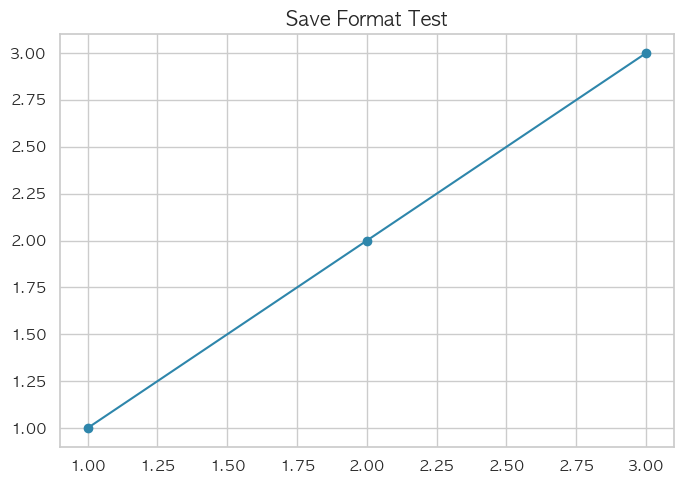

PNG dpi=150 for screens, dpi=300 for print; SVG for vector editing; PDF for formal reports.
화면용은 PNG dpi=150, 인쇄용은 dpi=300; 편집 가능한 벡터는 SVG; 공식 문서는 PDF.


In [8]:
# Business question: which file format should you hand off for Slack, for print,
# and for a designer who might need to edit it later?
# 비즈니스 질문: Slack 공유용, 인쇄용, 나중에 디자이너가 편집할 수도 있는 파일은
# 각각 어떤 포맷으로 넘겨야 하는가?

setup_plot_style()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([1, 2, 3], [1, 2, 3], marker='o', color='#2E86AB')
ax.set_title('Save Format Test')
plt.tight_layout()

# fig.savefig('report_web.png', dpi=150, bbox_inches='tight')     # Slack / email
# fig.savefig('report_print.png', dpi=300, bbox_inches='tight')   # print / high quality
# fig.savefig('report_vector.svg', bbox_inches='tight')           # editable vector
# fig.savefig('report_document.pdf', bbox_inches='tight')         # formal document
plt.show()

print("PNG dpi=150 for screens, dpi=300 for print; SVG for vector editing; PDF for formal reports.")
print("화면용은 PNG dpi=150, 인쇄용은 dpi=300; 편집 가능한 벡터는 SVG; 공식 문서는 PDF.")

## Example 6 — Practice: Apply All Five Styling Concepts (연습: 다섯 가지 스타일링 개념 모두 적용하기)

Fill in every `________` blank below. The cell runs with **no errors** even if you leave blanks — it just prints a reminder instead of drawing that part's chart.

아래 `________` 빈칸을 모두 채워보세요. 빈칸을 두어도 셀은 **에러 없이** 실행되며, 그 부분의 차트 대신 안내 메시지만 출력됩니다.

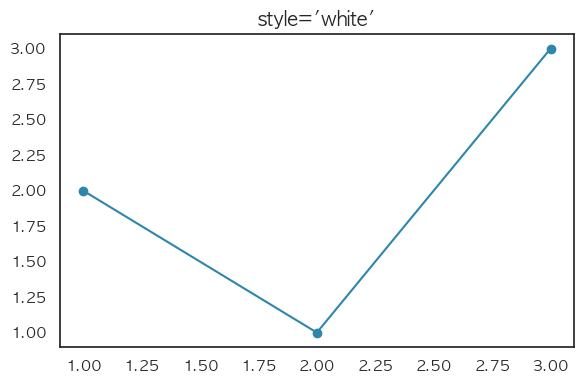

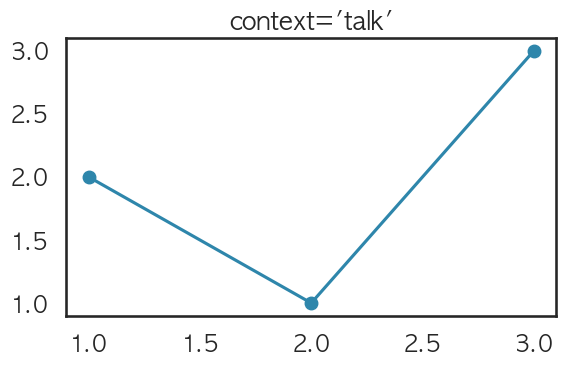

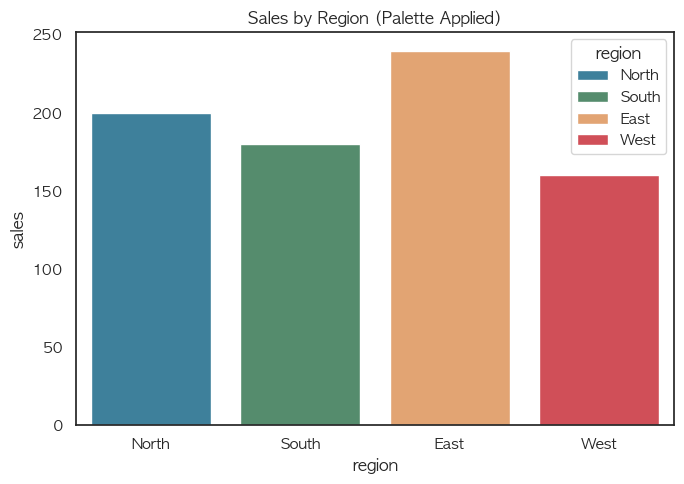

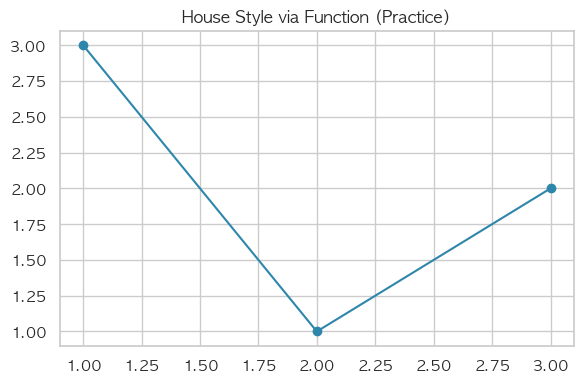

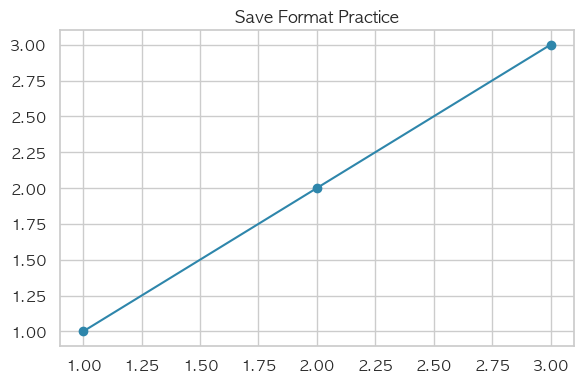

Saved practice_print.png at 300 dpi and practice_vector.svg


In [9]:
# ============================================================
# Practice -- fill in every ________ blank, then re-run the cell
# 연습 -- 아래 ________ 빈칸을 모두 채운 뒤 셀을 다시 실행하세요
# ============================================================
BLANK = "________"

def ready(*vals):
    return all(v != BLANK for v in vals)

# ---------- Part A: style -- pick a style with NO grid and a white background ----------
style_a = "white"   # TODO: which of darkgrid/whitegrid/dark/white/ticks has no grid AND a white background?

if ready(style_a):
    sns.set_style(style_a)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot([1, 2, 3], [2, 1, 3], marker='o', color='#2E86AB')
    ax.set_title(f"style='{style_a}'")
    plt.tight_layout()
    plt.show()
else:
    print("Part A \u270f\ufe0f  Fill in style_a above, then re-run.")

# ---------- Part B: context -- pick the size meant for presentation slides ----------
context_b = "talk"   # TODO: paper / notebook / talk / poster -- which is for slides on a screen?

if ready(context_b):
    sns.set_context(context_b)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot([1, 2, 3], [2, 1, 3], marker='o', color='#2E86AB')
    ax.set_title(f"context='{context_b}'")
    plt.tight_layout()
    plt.show()
    sns.set_context('notebook')  # reset
else:
    print("Part B \u270f\ufe0f  Fill in context_b above, then re-run.")

# ---------- Part C: palette -- make each bar a different palette color ----------
df_c = pd.DataFrame({'region': ['North', 'South', 'East', 'West'], 'sales': [200, 180, 240, 160]})
sns.set_palette(['#2E86AB', '#4C956C', '#F4A261', '#E63946'])

hue_col_c = "region"   # TODO: which column name goes in hue= to cycle the bar colors?
legend_c  = True   # TODO: True or False -- should the (redundant) legend be shown?

if ready(hue_col_c, legend_c):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.barplot(data=df_c, x='region', y='sales', hue=hue_col_c, legend=legend_c, ax=ax)
    ax.set_title('Sales by Region (Palette Applied)')
    plt.tight_layout()
    plt.show()
else:
    print("Part C \u270f\ufe0f  Fill in hue_col_c and legend_c above, then re-run.")

# ---------- Part D: reusable style function -- fill in what it customizes ----------
def practice_style():
    sns.set_theme(style='whitegrid', font='AppleGothic')
    plt.rcParams['axes.unicode_minus'] = False
    sns.set_palette(palette_d)

palette_d = ['#2E86AB', '#F4A261']   # TODO: a list of 2+ hex color strings for set_palette(), e.g. ['#2E86AB', '#F4A261']

if ready(palette_d):
    practice_style()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot([1, 2, 3], [3, 1, 2], marker='o')
    ax.set_title('House Style via Function (Practice)')
    plt.tight_layout()
    plt.show()
else:
    print("Part D \u270f\ufe0f  Fill in palette_d above, then re-run.")

# ---------- Part E: save formats -- pick the right dpi and vector extension ----------
print_dpi_e  = 300   # TODO: dpi value appropriate for a PRINTED report (150 or 300)?
vector_ext_e = "svg"   # TODO: file extension for an editable VECTOR format (not png)

if ready(print_dpi_e, vector_ext_e):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot([1, 2, 3], [1, 2, 3], marker='o', color='#2E86AB')
    ax.set_title('Save Format Practice')
    plt.tight_layout()
    # fig.savefig('practice_print.png', dpi=print_dpi_e, bbox_inches='tight')
    # fig.savefig(f'practice_vector.{vector_ext_e}', bbox_inches='tight')
    plt.show()
    print(f"Saved practice_print.png at {print_dpi_e} dpi and practice_vector.{vector_ext_e}")
else:
    print("Part E \u270f\ufe0f  Fill in print_dpi_e and vector_ext_e above, then re-run.")

---
# ⚠️ Common Mistakes (자주 하는 실수)

### Mistake 1 — Creating Axes Before Calling `set_style()` (Axes를 만든 후에 set_style() 호출)
`sns.set_style()` only affects Axes created AFTER it runs; Axes already made with `plt.subplots()` keep whatever style was active when they were created.  
sns.set_style()은 그 이후에 만들어지는 Axes에만 적용됩니다. 이미 plt.subplots()로 만든 Axes는 만들어질 당시의 스타일을 그대로 유지합니다.

✅ **Fix / 해결:** Always call `set_style()` (or `set_theme()`) before `plt.subplots()`, not after.

### Mistake 2 — Korean Text Breaking After `set_style()` (set_style() 이후 한글이 깨짐)
`set_style()` resets `rcParams`, including the font family — so a Korean font set earlier in the script gets silently wiped out and labels turn into tofu boxes.  
set_style()은 폰트 패밀리를 포함한 rcParams를 초기화합니다 -- 그래서 스크립트 앞부분에서 지정한 한글 폰트가 조용히 사라지고 라벨이 네모(□)로 깨집니다.

✅ **Fix / 해결:** Re-set the font AFTER `set_style()`, or use `sns.set_theme(style=..., font=...)` which does both in one call.

### Mistake 3 — `set_palette()` Doesn't Cycle Colors on a Plain `barplot` (set_palette()가 barplot에서 순환하지 않음)
In Seaborn 0.12+, `barplot(x='col', y='col2')` with no `hue=` paints every bar with only the palette's first color — the palette isn't ignored, but it isn't cycled either.  
Seaborn 0.12+에서 hue= 없이 barplot(x='col', y='col2')을 쓰면 모든 막대가 팔레트의 첫 번째 색으로만 칠해집니다 -- 팔레트가 무시되는 것은 아니지만 순환도 되지 않습니다.

✅ **Fix / 해결:** Set `hue=` to the same column as `x=` and add `legend=False` to cycle the palette per bar without a duplicate legend.

### Mistake 4 — Forgetting to Reset `context` After Using `'talk'` (context를 talk으로 바꾼 뒤 되돌리지 않음)
Once you call `sns.set_context('talk')` for one slide, every chart you draw afterward in the same session stays oversized, even ones meant for a normal notebook view.  
sns.set_context('talk')을 한 번 호출하면, 이후 같은 세션에서 그리는 모든 차트가 일반 노트북용이라도 계속 커진 채로 남습니다.

✅ **Fix / 해결:** Call `sns.set_context('notebook')` right after you're done with the presentation-sized chart.  

### Mistake 5 — Saving at Screen Resolution for a Printed Report (인쇄용 보고서에 화면 해상도로 저장)
The screen-friendly `dpi=150` (or lower) looks fine on a monitor but turns visibly blurry once printed on paper.  
화면에 적합한 dpi=150(또는 그 이하)은 모니터에서는 괜찮아 보이지만 종이에 인쇄하면 눈에 띄게 흐려집니다.

✅ **Fix / 해결:** Use `dpi=300` for anything that will be printed; `dpi=150` is enough for Slack/email/screen sharing.  

### Mistake 6 — Skipping `bbox_inches='tight'` (bbox_inches='tight' 생략)
Without it, `savefig()` can clip off a title, rotated tick labels, or a legend that sits outside the main axes area.  
이것 없이 savefig()를 쓰면 제목, 회전된 눈금 라벨, 또는 축 바깥에 있는 범례가 잘려나갈 수 있습니다.

✅ **Fix / 해결:** Add `bbox_inches='tight'` to every `savefig()` call by default.

---
# 💡 Tips (팁)
Useful tips or shortcuts / 유용한 팁과 단축법

- `sns.set_theme(style=..., font=..., context=...)` can set style, font, and context all in one call — the single most convenient way to start a script.<br>sns.set_theme(style=..., font=..., context=...)는 style, font, context를 한 번에 설정할 수 있습니다 -- 스크립트를 시작하는 가장 편리한 방법입니다.
- Removing the top and right spines (`ax.spines['top'].set_visible(False)`) is a simple, almost-always-safe way to make a chart look more polished.<br>위·오른쪽 테두리를 제거하는 것(ax.spines['top'].set_visible(False))은 차트를 더 정돈되어 보이게 하는 간단하고 거의 항상 안전한 방법입니다.
- Keep your `setup_plot_style()` function in one shared file (or the top of every notebook) so a brand-color change only needs to happen in one place.<br>setup_plot_style() 함수를 하나의 공유 파일(또는 모든 노트북 맨 위)에 두면 브랜드 컬러 변경이 한 곳에서만 이루어지면 됩니다.
- Save PNG *and* SVG at the same time by default — the SVG costs nothing extra and saves you from re-running everything later if someone needs to edit the chart.<br>기본적으로 PNG와 SVG를 동시에 저장하세요 -- SVG는 추가 비용이 거의 없고, 누군가 차트를 편집해야 할 때 나중에 전부 다시 실행하지 않아도 됩니다.
- `frameon=False` on `ax.legend()` removes the legend's border box for a cleaner look that matches a `whitegrid`/`ticks` style.<br>ax.legend()에 frameon=False를 주면 범례의 테두리 박스가 사라져 whitegrid·ticks 스타일과 더 잘 어울리는 깔끔한 모양이 됩니다.

---
# 🔗 Related Concepts (관련 개념)

```
Seaborn Advanced (Section 11)
   pairplot / FacetGrid / regplot / jointplot
        ↓
Styling & Export (Section 12)  ← you are here / 현재 위치
   style / context / palette / reusable function / save formats
   ("make it presentation-ready")
        ↓
Plotly Basics (Section 13)
   px.line / bar / scatter / histogram
        ↓
Plotly Advanced (Section 14)
        ↓
Tableau Public (Sections 15-17)
```

*How is today's topic connected to other concepts?*

**EN:** This section isn't a new chart type — it's the finishing layer that turns everything from Sections 2-11 into something you'd actually hand to a stakeholder. The dpi/format choices you make here (PNG vs SVG vs PDF) resurface almost identically in Section 14, where Plotly gives you the same PNG-vs-HTML export tradeoff, but for interactive charts instead of static ones.

**KR:** 이번 섹션은 새로운 차트 유형이 아니라, 섹션 2~11에서 배운 모든 것을 실제로 이해관계자에게 전달할 수 있는 수준으로 마무리하는 층입니다. 여기서 익힌 dpi·포맷 선택(PNG vs SVG vs PDF)은 섹션 14에서 거의 동일하게 다시 등장하는데, Plotly는 정적 차트 대신 인터랙티브 차트에 대해 같은 PNG-vs-HTML 내보내기 트레이드오프를 제공합니다.

---
# 💼 Business Example (비즈니스 예시)
*How would a Business Analyst use this?*

**Scenario / 시나리오:**

**EN:** You need to send a "channel sales trend" chart to your director for tomorrow's slide deck. The first version you make is functional but looks like a rough draft. Your director's slides use a specific brand palette and get projected on a screen, so text needs to be readable from the back of the room.

**KR:** 내일 슬라이드 덱에 들어갈 "채널별 매출 추이" 차트를 이사님께 보내야 합니다. 처음 만든 버전은 기능은 하지만 초안처럼 보입니다. 이사님의 슬라이드는 특정 브랜드 팔레트를 사용하고 화면에 프로젝터로 띄워지므로, 텍스트가 뒷자리에서도 읽혀야 합니다.

**To-do / 할 일:**
- [x] Apply the company's whitegrid theme + talk-sized context so it's readable when projected<br>화면 투사 시 읽기 좋도록 회사의 whitegrid 테마와 talk 크기의 context 적용하기
- [x] Apply the brand color palette consistently to both lines<br>두 선 모두에 브랜드 컬러 팔레트를 일관되게 적용하기
- [x] Remove clutter (top/right spines, boxed legend) so the data stands out<br>불필요한 요소(위·오른쪽 테두리, 범례 박스) 제거해 데이터가 돋보이게 하기
- [x] Save both a PNG for the slide and an SVG in case the design team needs to edit it<br>슬라이드용 PNG와 디자인팀이 편집할 수도 있는 SVG 둘 다 저장하기

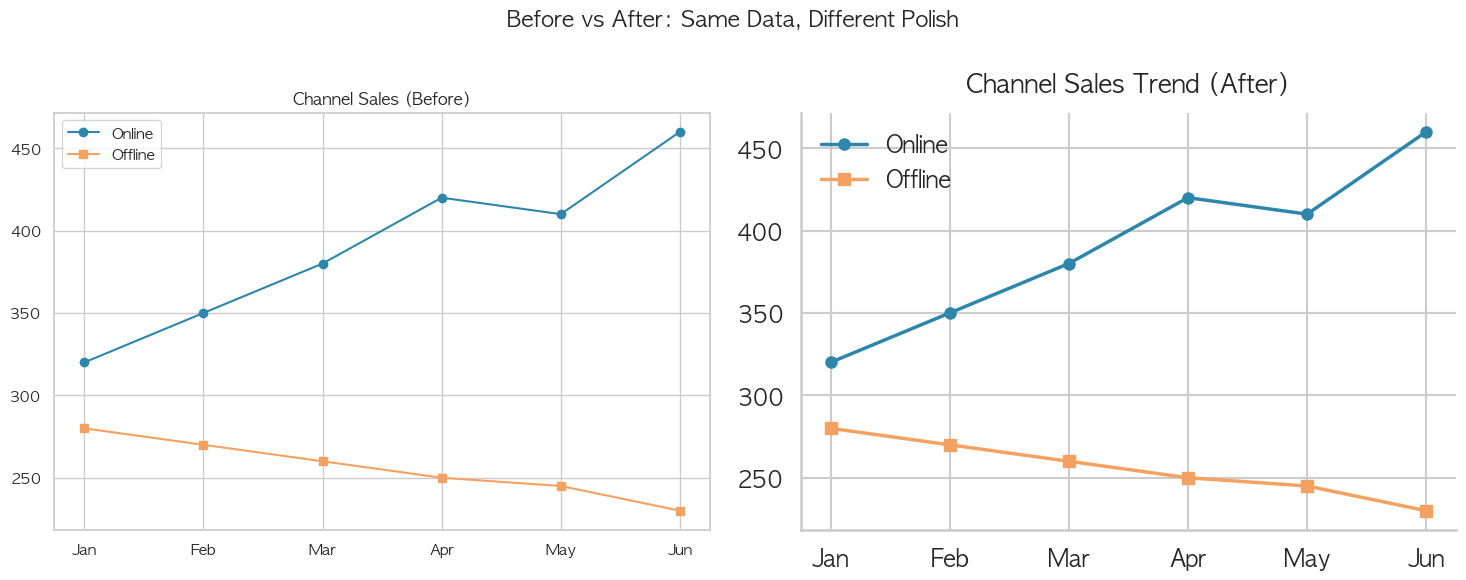

Saved: channel_sales_slide.png (150 dpi, for the slide)
저장됨: channel_sales_slide.png (150dpi, 슬라이드용)
Saved: channel_sales_slide.svg (vector, for the design team)
저장됨: channel_sales_slide.svg (벡터, 디자인팀용)


In [10]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
online = [320, 350, 380, 420, 410, 460]
offline = [280, 270, 260, 250, 245, 230]

fig = plt.figure(figsize=(15, 6))

# ---- BEFORE: default look, Axes created before any theme is set ----
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(months, online, marker='o', label='Online')
ax1.plot(months, offline, marker='s', label='Offline')
ax1.set_title('Channel Sales (Before)')
ax1.legend()

# ---- AFTER: theme + talk context + brand palette + decluttering ----
sns.set_theme(style='whitegrid', font='AppleGothic', context='talk')
plt.rcParams['axes.unicode_minus'] = False
brand_colors = ['#2E86AB', '#F4A261']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(months, online, marker='o', linewidth=2.5, markersize=8, color=brand_colors[0], label='Online')
ax2.plot(months, offline, marker='s', linewidth=2.5, markersize=8, color=brand_colors[1], label='Offline')
ax2.set_title('Channel Sales Trend (After)', fontweight='bold', pad=15)
ax2.legend(frameon=False, loc='upper left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Before vs After: Same Data, Different Polish', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

sns.set_context('notebook')  # reset so later cells in the session aren't affected

# fig.savefig('channel_sales_slide.png', dpi=150, bbox_inches='tight')
# fig.savefig('channel_sales_slide.svg', bbox_inches='tight')
print("Saved: channel_sales_slide.png (150 dpi, for the slide)")
print("저장됨: channel_sales_slide.png (150dpi, 슬라이드용)")
print("Saved: channel_sales_slide.svg (vector, for the design team)")
print("저장됨: channel_sales_slide.svg (벡터, 디자인팀용)")

---
# 📝 Summary (요약)
*Write today's concept in 3~5 sentences.*

**EN:** This section is about polish, not new chart types: Seaborn's `style` controls background and gridlines while `context` scales fonts/lines/markers for paper, notebook, talk, or poster use, and the two combine cleanly via `sns.set_theme(style=..., font=..., context=...)`. A fixed color palette (`sns.set_palette()`) keeps every chart in a report visually consistent, though a plain `barplot` needs `hue=` plus `legend=False` to actually cycle through it. Wrapping all of this into one `setup_plot_style()` function called once at the top of a script removes repetition and the ordering traps that come from calling `set_style()` after Axes already exist. Finally, the right export format depends on the destination: PNG at `dpi=150` for screens, `dpi=300` for print, SVG for anything that might need vector editing, and PDF for formal documents — always with `bbox_inches='tight'` to avoid clipped titles and labels.

**KR:** 이번 섹션은 새로운 차트 유형이 아니라 완성도에 관한 것입니다: Seaborn의 style은 배경과 격자선을, context는 논문·노트북·발표·포스터 용도에 맞게 글자·선·마커 크기를 조절하며, 이 둘은 sns.set_theme(style=..., font=..., context=...)로 깔끔하게 결합됩니다. 고정된 색상 팔레트(sns.set_palette())는 보고서의 모든 차트를 시각적으로 일관되게 유지하지만, 일반 barplot에서는 실제로 순환시키려면 hue=와 legend=False가 함께 필요합니다. 이 모든 것을 setup_plot_style() 함수 하나로 묶어 스크립트 맨 위에서 한 번만 호출하면 반복 작업과 Axes가 이미 만들어진 뒤 set_style()을 호출하는 순서 함정을 모두 없앨 수 있습니다. 마지막으로 올바른 내보내기 포맷은 용도에 따라 다릅니다: 화면용은 PNG dpi=150, 인쇄용은 dpi=300, 벡터 편집이 필요할 수 있는 경우는 SVG, 공식 문서는 PDF이며, 제목과 라벨이 잘리지 않도록 항상 bbox_inches='tight'를 함께 씁니다.

---
# 📌 One Sentence Summary (한 문장 요약)
Today's topic in ONE sentence. / 오늘의 주제를 한 문장으로.

> **EN:** Seaborn's theme system (`style` + `context`), a fixed color palette wrapped in a reusable function, and the right save format (PNG/SVG/PDF with the right dpi) are what turn a functionally correct chart into one that's actually ready to hand to a stakeholder.

> **KR:** Seaborn의 테마 시스템(style + context), 재사용 가능한 함수로 감싼 고정 색상 팔레트, 그리고 올바른 저장 포맷(적절한 dpi의 PNG/SVG/PDF)이 기능적으로 맞는 차트를 실제로 이해관계자에게 건넬 수 있는 차트로 바꿔줍니다.

---
# ❓ Review Questions (복습 질문)

**Q1 (EN).** Why does calling `sns.set_style('whitegrid')` after `fig, ax = plt.subplots()` fail to change that axis's appearance?
**Q1 (KR).** `fig, ax = plt.subplots()` 이후에 `sns.set_style('whitegrid')`를 호출해도 그 축의 모양이 바뀌지 않는 이유는 무엇인가요?

**Q2 (EN).** Which `context` value should you use before building a chart for a live presentation, and why?
**Q2 (KR).** 실시간 발표용 차트를 만들기 전에 어떤 context 값을 사용해야 하며, 이유는 무엇인가요?

**Q3 (EN).** Why doesn't `sns.barplot(data=df, x='channel', y='revenue')` cycle through a palette set with `sns.set_palette()`, and what two things fix it?
**Q3 (KR).** `sns.barplot(data=df, x='channel', y='revenue')`가 `sns.set_palette()`로 지정한 팔레트를 순환하지 않는 이유는 무엇이며, 무엇 두 가지를 추가하면 해결되나요?

**Q4 (EN).** What's the main benefit of wrapping style/font/palette setup into a single `setup_plot_style()` function instead of writing the same 5 lines in every notebook?
**Q4 (KR).** 같은 5줄을 매 노트북에 적는 대신 style·font·palette 설정을 `setup_plot_style()` 함수 하나로 묶는 주된 이점은 무엇인가요?

**Q5 (EN).** You need to hand a chart to a designer who might want to resize or recolor it later without quality loss. Which file format should you export, and why not PNG?
**Q5 (KR).** 나중에 화질 손실 없이 크기를 조정하거나 색을 바꿀 수도 있는 디자이너에게 차트를 넘겨야 합니다. 어떤 파일 포맷으로 내보내야 하며, 왜 PNG는 안 되나요?

---
*📅 Try answering these again in a few days. / 며칠 후 다시 답해보세요.*